# Week 11 Lab — SOLUTIONS — Mini-Research: FDI & Growth Panel; Market Regime Dating

**MANG2074 Financial Econometrics 1**

**Objectives**

- Run a complete panel-data research exercise: pooled/FE/RE, Hausman, clustered SEs, interpretation.
- Run a complete regime-switching exercise: estimation, regime dating, smoothed vs filtered probabilities.
- Practise writing results up the way the coursework requires.

**Data**

- `../data/fd_growth.csv` — balanced panel: 28 countries (`id`) × 16 years (`t`, 2002–2017); `gdpgrowth`, `FDI`, `schooling`, `investment`, `trade`, `inflation`, ...
- `../data/data_monthly.csv` — monthly returns, 1985–2023.


# Part A — Does FDI promote economic growth?

## Setup and data familiarisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels import PooledOLS, PanelOLS, RandomEffects
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

g = pd.read_csv('../data/fd_growth.csv')
print(g.groupby('id').size().describe())     # balanced? 28 countries x 16 years
panel = g.set_index(['id', 't'])
print(panel[['gdpgrowth', 'FDI', 'schooling', 'investment', 'trade', 'inflation']].describe().round(2))

count    28.0
mean     16.0
std       0.0
min      16.0
25%      16.0
50%      16.0
75%      16.0
max      16.0
dtype: float64
       gdpgrowth     FDI  schooling  investment   trade  inflation
count     448.00  448.00     448.00      448.00  448.00     448.00
mean        2.16    6.81      10.34       23.37   99.16       4.26
std         3.39   12.33       2.22        5.63   98.30       6.05
min       -11.85  -58.32       4.60       11.96   20.69     -16.91
25%         0.62    1.37       8.90       19.95   46.80       1.12
50%         1.80    2.57      10.95       22.15   59.94       2.45
75%         3.80    5.88      12.00       25.27  100.03       5.88
max        23.99   86.59      14.10       45.69  442.62      41.12


**What to interpret.** A balanced panel: every one of the 28 countries appears in all 16 years. FDI inflows average ~7% of GDP but with wild dispersion (−58% to +87% — financial-centre economies and divestment episodes); growth averages 2.2%. Heavy tails in FDI and inflation argue for robustness checks later.

## Task A1 — Pooled OLS benchmark

In [2]:
f = 'gdpgrowth ~ 1 + FDI + schooling + investment + trade + inflation'
pooled = PooledOLS.from_formula(f, panel).fit()
print(pooled)


                          PooledOLS Estimation Summary                          
Dep. Variable:              gdpgrowth   R-squared:                        0.2499
Estimator:                  PooledOLS   R-squared (Between):              0.8131
No. Observations:                 448   R-squared (Within):               0.0070
Date:                Thu, Jun 11 2026   R-squared (Overall):              0.2499
Time:                        01:32:20   Log-likelihood                   -1117.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      29.445
Entities:                          28   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(5,442)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):             29.445
                            

**What to interpret.** Pooled OLS puts the FDI coefficient at ≈ 0.032: a country-year with FDI higher by 1% of GDP grows ~0.03pp faster — tiny relative to a 3.4pp growth standard deviation. Domestic `investment` looks like the strong correlate (~0.26). But pooling attributes *all* cross-country level differences to the included regressors; institutions, geography and the like are lurking in the error term, correlated with everything.

## Task A2 — Fixed and random effects

In [3]:
fe = PanelOLS.from_formula(f + ' + EntityEffects', panel).fit()
re = RandomEffects.from_formula(f, panel).fit()

table = pd.DataFrame({'pooled': pooled.params, 'FE': fe.params, 'RE': re.params})
print(table.round(4))
print()
print(fe)


            pooled      FE      RE
Intercept  -3.1111  7.5908 -2.4257
FDI         0.0321  0.0416  0.0328
schooling  -0.1595 -0.9818 -0.1916
investment  0.2558  0.0775  0.2415
trade       0.0023  0.0246  0.0024
inflation   0.1175  0.0447  0.1095

                          PanelOLS Estimation Summary                           
Dep. Variable:              gdpgrowth   R-squared:                        0.0643
Estimator:                   PanelOLS   R-squared (Between):             -1.1517
No. Observations:                 448   R-squared (Within):               0.0643
Date:                Thu, Jun 11 2026   R-squared (Overall):             -0.3021
Time:                        01:32:20   Log-likelihood                   -1087.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5.7009
Entities:                          28   P-value                           0.0000
Avg Obs:                 

**What to interpret.** Movements to watch: `investment` collapses (0.26 → 0.08, insignificant) — its pooled 'effect' was mostly a *between-country* correlation (high-investment countries grow faster) rather than within-country timing; `schooling` turns strongly negative within countries (rising enrolment during slow-growth periods — almost certainly not causal); `FDI` *rises* slightly to ≈ 0.042 and remains significant on default SEs. RE hugs the pooled estimates, hinting its orthogonality assumption is dubious — formally tested next.

## Task A3 — Hausman test

In [4]:
slopes = ['FDI', 'schooling', 'investment', 'trade', 'inflation']
b_diff = fe.params[slopes] - re.params[slopes]
V_diff = fe.cov.loc[slopes, slopes] - re.cov.loc[slopes, slopes]
H = float(b_diff.T @ np.linalg.inv(V_diff.values) @ b_diff)
p = stats.chi2.sf(H, df=len(slopes))
print(f"Hausman H = {H:.2f}, chi2(5) p-value = {p:.3g}")


Hausman H = 31.45, chi2(5) p-value = 7.65e-06


**What to interpret.** H ≈ 31, p < 0.0001: reject the null that country effects are uncorrelated with the regressors. Random effects is inconsistent here; **fixed effects is the defensible estimator** (remember the direction: rejection ⇒ FE).

## Task A4 — Honest standard errors

In [5]:
fe_cl = PanelOLS.from_formula(f + ' + EntityEffects', panel)\
               .fit(cov_type='clustered', cluster_entity=True)

print(pd.DataFrame({'coef': fe.params, 't (default)': fe.tstats,
                    't (clustered)': fe_cl.tstats}).round(3))


             coef  t (default)  t (clustered)
Intercept   7.591        2.572          1.973
FDI         0.042        2.648          0.927
schooling  -0.982       -3.506         -2.597
investment  0.078        1.281          1.071
trade       0.025        2.907          2.216
inflation   0.045        1.196          0.437


**What to interpret.** The crunch result of Project A: with country-clustered SEs the FDI t-statistic falls from ≈ 2.7 to ≈ **0.9** — the apparent significance was an artefact of treating 16 serially correlated years per country as independent. With only 28 clusters, honest inference says we **cannot distinguish the FDI–growth relation from zero**. `schooling` and `trade` retain more strength but the same haircut applies. This single table is why Petersen (2009)-style clustering is non-negotiable in panel work.

## Task A5 — Robustness: time effects

In [6]:
fe2 = PanelOLS.from_formula(f + ' + EntityEffects + TimeEffects', panel)\
              .fit(cov_type='clustered', cluster_entity=True)
print(pd.DataFrame({'FE': fe.params, 'FE + time effects': fe2.params}).round(4))
print(f"\nFDI: coef = {fe2.params['FDI']:.4f}, clustered t = {fe2.tstats['FDI']:.2f}")


                FE  FE + time effects
Intercept   7.5908            -1.4003
FDI         0.0416             0.0398
schooling  -0.9818            -0.0260
investment  0.0775             0.0703
trade       0.0246             0.0199
inflation   0.0447            -0.0133

FDI: coef = 0.0398, clustered t = 0.86


**What to interpret.** Adding year dummies (absorbing the global cycle, especially 2008–09) leaves the FDI point estimate near 0.04 — the *coefficient* is stable, which is mildly reassuring about global-shock confounding — but clustered inference remains weak. Stability-without-significance is a common and honest empirical outcome.

## Task A6 — Mini-report A (model answer)

**Question.** Do FDI inflows raise GDP growth? **Data/method.** Balanced panel, 28 countries × 16 years (2002–17); pooled OLS, fixed and random effects with controls (schooling, investment, trade, inflation); Hausman test; country-clustered SEs; two-way FE robustness. **Findings.** The Hausman test (H ≈ 31, p < 0.001) rejects RE, so we report FE. The within-country FDI coefficient is ≈ +0.04pp of growth per 1pp of FDI/GDP and is stable to year effects, but with country-clustered standard errors it is statistically indistinguishable from zero (t ≈ 0.9). Economically the point estimate is modest: a one-SD rise in FDI (~12pp) maps to ~0.5pp of growth. **Limitations.** (i) Reverse causality — FDI plausibly chases anticipated growth; FE does not fix this (instruments or dynamic panel GMM would be needed). (ii) Time-varying confounders (reform episodes, commodity cycles) survive FE. We therefore report an association, not a causal effect.

# Part B — Dating bull and bear markets

## Task B1 — Estimate the switching model

In [7]:
d = pd.read_csv('../data/data_monthly.csv', index_col=0, parse_dates=True).asfreq('MS')
r = (100 * d['return']).dropna()

ms = sm.tsa.MarkovRegression(r, k_regimes=2, switching_variance=True)
res = ms.fit()
print(res.summary())

p00 = res.params['p[0->0]']; p11 = 1 - res.params['p[1->0]']
print(f"\nregime 0 (calm):      mean = {res.params['const[0]']:.2f}%, vol = {np.sqrt(res.params['sigma2[0]']):.2f}%, expected duration = {1/(1-p00):.0f} months")
print(f"regime 1 (turbulent): mean = {res.params['const[1]']:.2f}%, vol = {np.sqrt(res.params['sigma2[1]']):.2f}%, expected duration = {1/(1-p11):.0f} months")


                        Markov Switching Model Results                        
Dep. Variable:                 return   No. Observations:                  457
Model:               MarkovRegression   Log Likelihood               -1772.842
Date:                Thu, 11 Jun 2026   AIC                           3557.683
Time:                        01:32:20   BIC                           3582.432
Sample:                    02-01-1985   HQIC                          3567.431
                         - 02-01-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2081      0.650      3.396      0.001       0.934       3.483
sigma2        76.6931     11.394      6.731      0.0

**What to interpret.** Same structure as Week 9: a calm regime (mean ≈ +2.2%/month, vol ≈ 8.8%, average spell ≈ 3 years) and a turbulent regime (mean ≈ 0.4% ≈ statistically zero, vol ≈ 17.9%, average spell ≈ 1.5 years). High volatility buys no extra average return — risk is not rewarded within the bear state.

## Task B2 — Regime chronology

Bear-regime chronology:
     start        end  months
1985-02-01 1985-05-01       4
1986-07-01 1987-12-01      18
1990-07-01 1991-07-01      13
1993-05-01 1994-11-01      19
1996-06-01 2002-07-01      74
2004-10-01 2005-03-01       6
2007-10-01 2008-12-01      15


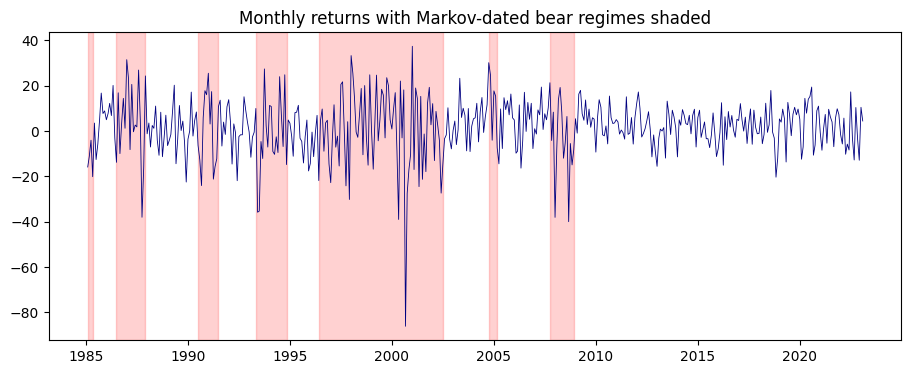

In [8]:
prob_bear = res.smoothed_marginal_probabilities[1]
bear = prob_bear > 0.5

groups = bear.ne(bear.shift()).cumsum()
spells = (pd.DataFrame({'bear': bear, 'g': groups})
          .groupby('g')
          .agg(start=('bear', lambda s: s.index.min()),
               end=('bear', lambda s: s.index.max()),
               is_bear=('bear', 'first'), months=('bear', 'size')))
chron = spells[spells['is_bear']][['start', 'end', 'months']]
print("Bear-regime chronology:")
print(chron.to_string(index=False))

plt.figure(figsize=(11, 4))
plt.plot(r, lw=0.6, color='navy')
for _, row in chron.iterrows():
    plt.axvspan(row['start'], row['end'], color='red', alpha=0.18)
plt.title('Monthly returns with Markov-dated bear regimes shaded')
plt.show()


**What to interpret.** The shaded chronology picks out the volatility around the 1987 crash, the early-1990s recession, a long turbulent block spanning the late-1990s boom and dot-com bust, and 2007–08. Because the regimes are *volatility-defined*, exuberant-but-violent periods are classified "bear/turbulent" along with crashes — a useful reminder that the model dates *risk states*, not price directions.

## Task B3 — Smoothed vs filtered: the look-ahead trap

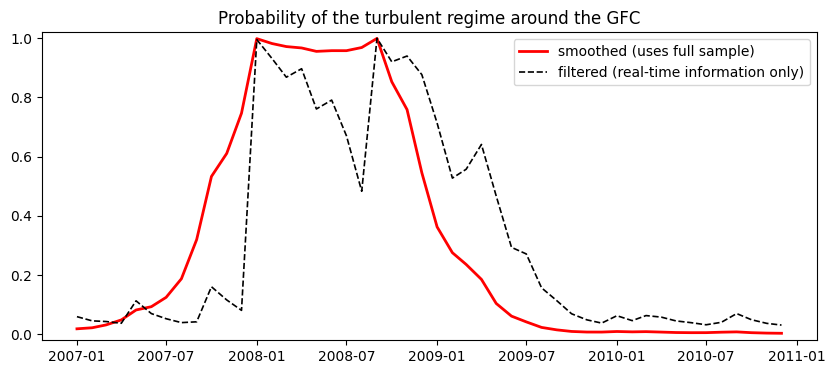

In [9]:
window = slice('2007-01-01', '2010-12-01')
sm_p = res.smoothed_marginal_probabilities[1][window]
fi_p = res.filtered_marginal_probabilities[1][window]

plt.figure(figsize=(10, 4))
plt.plot(sm_p, 'r-', lw=2, label='smoothed (uses full sample)')
plt.plot(fi_p, 'k--', lw=1.2, label='filtered (real-time information only)')
plt.legend(); plt.ylim(-0.02, 1.02)
plt.title('Probability of the turbulent regime around the GFC')
plt.show()


**What to interpret.** The smoothed probability switches on cleanly and early — but it is allowed to peek at 2009–2023 data when classifying 2007. The filtered probability, which uses only information available *at the time*, is noisier and recognises the regime change with a lag of some months. Any backtest that trades on smoothed probabilities is structurally cheating; the realistic information set is the dashed line. The gap between the two curves is, quite literally, a picture of look-ahead bias.

## Task B4 — Mini-report B (model answer)

A two-regime Markov switching model on monthly returns (1985–2023) identifies a **calm state** (mean +2.2%/month, vol 8.8%, persisting ~36 months) and a **turbulent state** (mean ≈ 0, vol 17.9%, persisting ~18 months); transition probabilities of 0.97/0.94 confirm regimes are persistent market conditions rather than noise. The smoothed chronology shades the 1987 episode, the early-1990s slowdown, an extended high-volatility block around the dot-com boom-bust, and the global financial crisis. For investment practice the key caveat is informational: smoothed probabilities condition on the full sample and date regimes with hindsight, while the filtered (real-time) probabilities lag turning points by several months and are far noisier — so regime models are better treated as risk-measurement and scenario tools than as timing signals, and any backtest must be built on filtered output.